# Schwartz-Smith Two-Factor Model Calibration and Heston Comparison

This notebook demonstrates:
1. Simulating synthetic WTI Crude Oil futures prices and options under the Schwartz-Smith two-factor model.
2. Calibrating the Schwartz-Smith model parameters from the futures price history using a Kalman Filter.
3. Estimating state variables and pricing options on the final date using both Fourier-Cosine (COS) and Black-76 solvers.
4. Calibrating the Classic Heston model to the resulting implied volatility surface.
5. Comparing option prices and implied volatilities between the calibrated Schwartz-Smith and Heston models.


In [1]:
import os
import sys
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Ensure the project root directory is in path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import pricing engines and data adapters
from src.pricing.schwartz_smith import (
    schwartz_smith_price_black76,
    schwartz_smith_price_cos,
    price_option_cos,
    calibrate_schwartz_smith,
    run_kalman_filter,
    price_option_cos_pt,
    schwartz_smith_price_black76_pt
)
from src.pricing.heston import (
    heston_iv_surface,
    calibrate_heston
)
from src.market.commodity_data import (
    CMECommodityDataAdapter,
    generate_synthetic_options_data,
    wti_futures_expiry,
    wti_options_expiry,
    parse_futures_code,
    implied_vol_black76
)

print("Imports successful!")


Imports successful!


## Step 1: Generate Synthetic Futures and Options Panel Data

We simulate a historical panel of WTI Crude Oil futures and options prices over 52 weekly dates. We use a set of realistic WTI true parameters for the Schwartz-Smith model.


In [2]:
np.random.seed(42)

# True parameters
true_params = {
    "kappa": 0.8,
    "sigma_chi": 0.25,
    "rho": 0.3,
    "sigma_xi": 0.12,
    "mu": 0.06,
    "lambda_chi": 0.05,
    "mu_star": 0.03,
    "sigma_e": 0.005
}

# Create 52 weekly dates
start_date = datetime.date(2026, 1, 1)
dates = [start_date + datetime.timedelta(weeks=i) for i in range(52)]

# Grid parameters for comparison
months_ahead = [1, 3, 6, 9, 12]
strike_pcts = [0.85, 0.90, 0.95, 1.0, 1.05, 1.10, 1.15]

# Generate synthetic options and futures data
print("Generating synthetic data...")
opts_df, futs_df = generate_synthetic_options_data(
    valuation_dates=dates,
    months_ahead=months_ahead,
    strike_pcts=strike_pcts,
    ss_params=true_params,
    init_chi=0.05,
    init_xi=np.log(75.0),
    r=0.04,
    noise_std=0.01  # Realistic noise
)
print(f"Generated {len(futs_df)} futures prices and {len(opts_df)} options prices.")


Generating synthetic data...


Generated 260 futures prices and 3640 options prices.


## Step 2: Kalman Filter Schwartz-Smith Calibration

We run the Kalman Filter calibrator to estimate the Schwartz-Smith model parameters from the futures price history.


In [3]:
# Pivot futures prices to shape (num_dates, num_contracts)
futs_pivoted = futs_df.pivot(index="valuation_date", columns="tenor", values="price")
futs_codes_pivoted = futs_df.pivot(index="valuation_date", columns="tenor", values="contract_code")

dates_arr = futs_pivoted.index.tolist()
futures_prices = futs_pivoted.values

# Build maturities matrix
num_dates, num_contracts = futures_prices.shape
maturities = np.zeros((num_dates, num_contracts))
for t_idx, val_dt in enumerate(dates_arr):
    for c_idx, tenor in enumerate(futs_pivoted.columns):
        code = futs_codes_pivoted.iloc[t_idx, c_idx]
        parsed = parse_futures_code(code, ref_year=2026)
        expiry = wti_futures_expiry(parsed["year"], parsed["month"])
        maturities[t_idx, c_idx] = (expiry - val_dt).days / 365.0

print("Running Schwartz-Smith calibration via Kalman Filter...")
init_guess = [0.6, 0.20, 0.2, 0.10, 0.05, 0.02, 0.02, 0.01]
cal_ss = calibrate_schwartz_smith(dates_arr, futures_prices, maturities, init_guess=init_guess)

print("\n--- Calibration Results ---")
for k, v in cal_ss.items():
    if k in true_params:
        print(f"{k:12s}: Calibrated = {v:8.4f}, True = {true_params[k]:8.4f}, Error = {abs(v - true_params[k]):8.4f}")
    else:
        print(f"{k:12s}: {v}")


Running Schwartz-Smith calibration via Kalman Filter...



--- Calibration Results ---
kappa       : Calibrated =   0.6073, True =   0.8000, Error =   0.1927
sigma_chi   : Calibrated =   0.2355, True =   0.2500, Error =   0.0145
rho         : Calibrated =   0.2184, True =   0.3000, Error =   0.0816
sigma_xi    : Calibrated =   0.0882, True =   0.1200, Error =   0.0318
mu          : Calibrated =  -0.0014, True =   0.0600, Error =   0.0614
lambda_chi  : Calibrated =   0.0698, True =   0.0500, Error =   0.0198
mu_star     : Calibrated =   0.0614, True =   0.0300, Error =   0.0314
sigma_e     : Calibrated =   0.0010, True =   0.0050, Error =   0.0040
success     : True
log_likelihood: 1137.8768134101551


## Step 3: Extract Filtered State Variables at Final Date

Using the calibrated parameters, we run the Kalman Filter again to extract the state variables ($\\chi_T, \\xi_T$) at the last valuation date.


In [4]:
ll, states, covs = run_kalman_filter(
    dates_arr, futures_prices, maturities,
    cal_ss["kappa"], cal_ss["sigma_chi"], cal_ss["rho"], cal_ss["sigma_xi"],
    cal_ss["mu"], cal_ss["lambda_chi"], cal_ss["mu_star"], cal_ss["sigma_e"]
)

cal_chi = states[-1, 0]
cal_xi = states[-1, 1]
print(f"Calibrated final states at {dates_arr[-1]}: chi_T = {cal_chi:.4f}, xi_T = {cal_xi:.4f}")


Calibrated final states at 2026-12-24: chi_T = 0.3027, xi_T = 4.2985


## Step 4: Construct the target Implied Volatility Surface on the Final Date

We extract options at the final valuation date and calculate the target IV surface on a clean $(T_{opt}, k)$ grid based on the simulated strike percents.


In [5]:
last_date = dates_arr[-1]
opts_last = opts_df[opts_df["valuation_date"] == last_date].copy()
futs_last = futs_df[futs_df["valuation_date"] == last_date].copy()

adapter = CMECommodityDataAdapter(ref_year=2026)
matched_last = adapter.match_options_to_futures(opts_last, futs_last)

# Compute implied volatility for matched options
matched_last["implied_vol"] = matched_last.apply(
    lambda r: implied_vol_black76(r["option_price"], r["futures_price"], r["strike"], r["T_opt"], 0.04, r["option_type"]),
    axis=1
)

# Construct grid of unique maturities and log-moneyness based on strike_pcts
T_grid = sorted(matched_last["T_opt"].unique())
K_grid = np.log(strike_pcts)

print(f"Maturities grid T_grid: {T_grid}")
print(f"Log-moneyness grid K_grid: {K_grid}")

# Fill target IV surface matrix of shape (len(T_grid), len(K_grid))
iv_target = np.zeros((len(T_grid), len(K_grid)))
for i, T in enumerate(T_grid):
    opts_T = matched_last[np.abs(matched_last["T_opt"] - T) < 1e-4]
    for j, pct in enumerate(strike_pcts):
        subset = opts_T[np.abs(opts_T["strike"] / opts_T["futures_price"] - pct) < 0.02]
        if len(subset) > 0:
            iv_target[i, j] = subset["implied_vol"].mean()
        else:
            iv_target[i, j] = 0.20

print("\nTarget IV Surface:")
print(pd.DataFrame(iv_target, index=[f"T={t:.3f}" for t in T_grid], columns=[f"k={k:.2f}" for k in K_grid]))


Maturities grid T_grid: [np.float64(0.1506849315068493), np.float64(0.39452054794520547), np.float64(0.6465753424657534), np.float64(0.8958904109589041)]
Log-moneyness grid K_grid: [-0.16251893 -0.10536052 -0.05129329  0.          0.04879016  0.09531018
  0.13976194]

Target IV Surface:
          k=-0.16   k=-0.11   k=-0.05    k=0.00    k=0.05    k=0.10    k=0.14
T=0.151  0.292648  0.292708  0.292505  0.292396  0.292399  0.292260  0.292064
T=0.395  0.274832  0.274790  0.274760  0.274723  0.274682  0.274784  0.274648
T=0.647  0.258406  0.258431  0.258469  0.258450  0.258539  0.258450  0.258448
T=0.896  0.244906  0.244819  0.244819  0.244793  0.244774  0.244829  0.244767


## Step 5: Heston Model Calibration to the IV Surface

We calibrate the classic Heston model to the extracted target IV surface using `calibrate_heston`.


In [6]:
print("Running Heston calibration...")
res_heston = calibrate_heston(iv_target, np.array(T_grid), np.array(K_grid), max_iter=150)

print("\n--- Heston Calibrated Parameters ---")
for k, v in res_heston["params"].items():
    print(f"{k:8s}: {v:.4f}")
print(f"Final Calibration Loss (MSE): {res_heston['loss']:.6f}")


Running Heston calibration...



--- Heston Calibrated Parameters ---
kappa   : 1.5000
theta   : 0.0288
sigma   : 0.2908
rho     : -0.4938
v0      : 0.0940
Final Calibration Loss (MSE): 0.000124


## Step 6: Pricing Comparison (Schwartz-Smith vs Heston)

We compute option prices using the calibrated Schwartz-Smith parameters via both:
1. Fourier-Cosine (COS) method
2. Black-76 solver (using the conditional variance)

And we compare them against the calibrated Heston model's implied volatilities and prices.


In [7]:
# Construct mapping from T_opt to actual futures price and futures maturity
T_mapping = {row["T_opt"]: (row["futures_price"], row["T_fut"]) for _, row in matched_last.iterrows()}

# Generate prediction surfaces
ss_iv_black = np.zeros((len(T_grid), len(K_grid)))
ss_iv_cos = np.zeros((len(T_grid), len(K_grid)))

for i, T in enumerate(T_grid):
    F, T_fut = T_mapping[T]
    for j, k_val in enumerate(K_grid):
        K = F * np.exp(k_val)
        otype = "C"
            
        p_black = schwartz_smith_price_black76(
            0.0, T, T_fut, K, 0.04, cal_chi, cal_xi,
            cal_ss["kappa"], cal_ss["sigma_chi"], cal_ss["rho"], cal_ss["sigma_xi"],
            cal_ss["mu_star"], cal_ss["lambda_chi"], option_type=otype
        )
        p_cos = price_option_cos(
            0.0, T, T_fut, K, 0.04, cal_chi, cal_xi,
            cal_ss["kappa"], cal_ss["sigma_chi"], cal_ss["rho"], cal_ss["sigma_xi"],
            cal_ss["mu_star"], cal_ss["lambda_chi"], option_type=otype, N=256, L=12.0
        )
        
        ss_iv_black[i, j] = implied_vol_black76(p_black, F, K, T, 0.04, otype)
        ss_iv_cos[i, j] = implied_vol_black76(p_cos, F, K, T, 0.04, otype)

# Predict IV under Heston
heston_iv_pred = heston_iv_surface(res_heston["params"], np.array(T_grid), np.array(K_grid))

# Compute RMSEs against Target
rmse_ss_black = np.sqrt(np.mean((ss_iv_black - iv_target)**2))
rmse_ss_cos = np.sqrt(np.mean((ss_iv_cos - iv_target)**2))
rmse_heston = np.sqrt(np.mean((heston_iv_pred - iv_target)**2))

print(f"Schwartz-Smith (Black-76) IV RMSE: {rmse_ss_black:.6f}")
print(f"Schwartz-Smith (COS Method) IV RMSE: {rmse_ss_cos:.6f}")
print(f"Heston Model IV RMSE:               {rmse_heston:.6f}")


Schwartz-Smith (Black-76) IV RMSE: 0.029236
Schwartz-Smith (COS Method) IV RMSE: 0.029236
Heston Model IV RMSE:               0.011148


## Step 7: Plot Implied Volatility Surfaces

We plot the implied volatility curves across log-moneyness for different maturities to visually compare the fit of the Schwartz-Smith and Heston models.


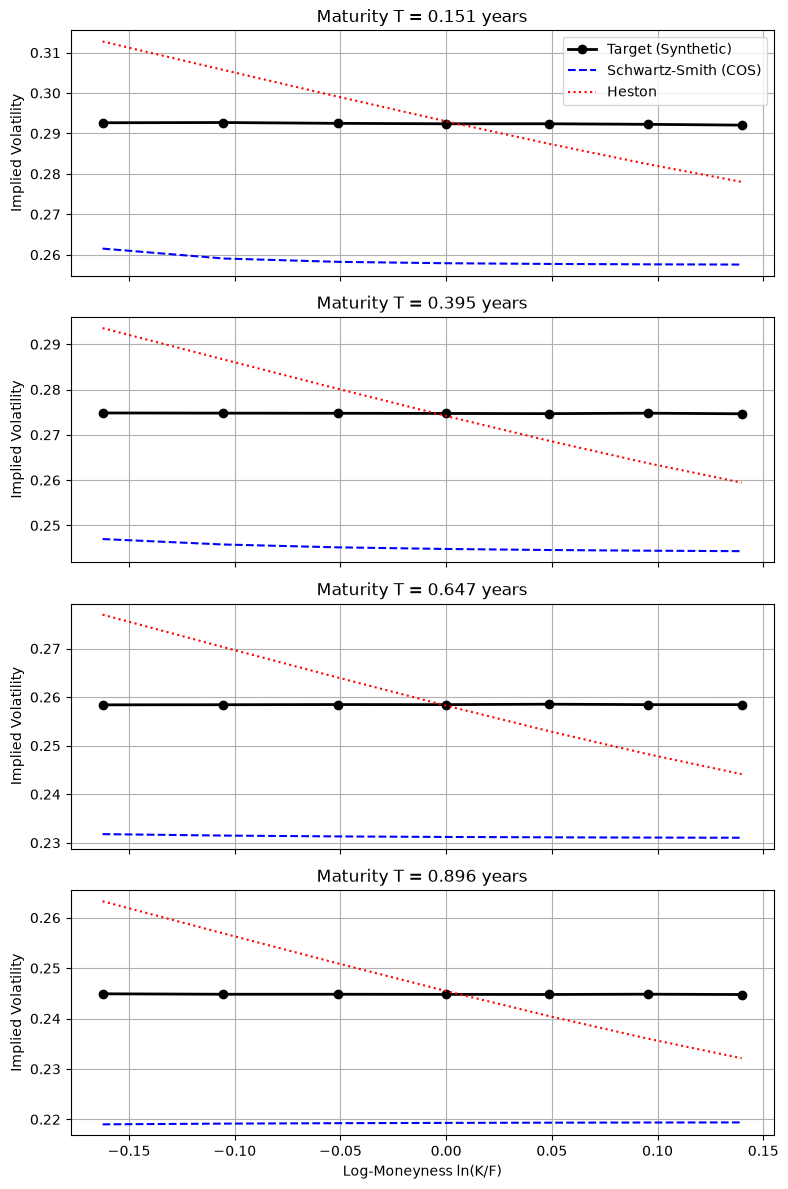

In [8]:
fig, axes = plt.subplots(len(T_grid), 1, figsize=(8, 3 * len(T_grid)), sharex=True)
if len(T_grid) == 1:
    axes = [axes]

for i, T in enumerate(T_grid):
    ax = axes[i]
    ax.plot(K_grid, iv_target[i], 'ko-', label="Target (Synthetic)", linewidth=2)
    ax.plot(K_grid, ss_iv_cos[i], 'b--', label="Schwartz-Smith (COS)")
    ax.plot(K_grid, heston_iv_pred[i], 'r:', label="Heston")
    ax.set_ylabel("Implied Volatility")
    ax.set_title(f"Maturity T = {T:.3f} years")
    ax.grid(True)
    if i == 0:
        ax.legend()

axes[-1].set_xlabel("Log-Moneyness ln(K/F)")
plt.tight_layout()
plt.savefig("../images/commodity_iv_comparison.png")
plt.show()
